In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot
from ot.datasets import make_1D_gauss as gauss

### Generate data

In [2]:
n = 100  # nb bins

# bin positions
x = np.arange(n, dtype=np.float64)

# Gaussian distributions
a = gauss(n, m=20, s=5)  # m= mean, s= std
b = gauss(n, m=60, s=10)

# make distributions unbalanced
b *= 5.0

# loss matrix
M = ot.dist(x.reshape((n, 1)), x.reshape((n, 1)))
M /= M.max()

### Plot distributions and loss matrix

(<Axes: >, <Axes: >, <Axes: >)

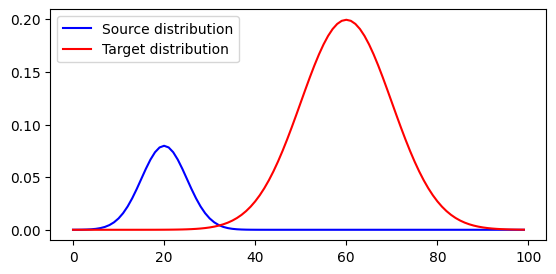

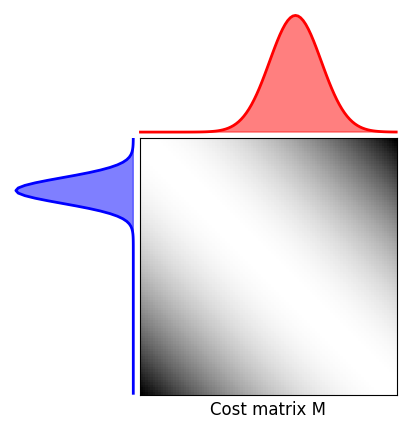

In [3]:
pl.figure(1, figsize=(6.4, 3))
pl.plot(x, a, "b", label="Source distribution")
pl.plot(x, b, "r", label="Target distribution")
pl.legend()

# plot distributions and loss matrix

pl.figure(2, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, M, "Cost matrix M")

### Solve Unbalanced Sinkhorn

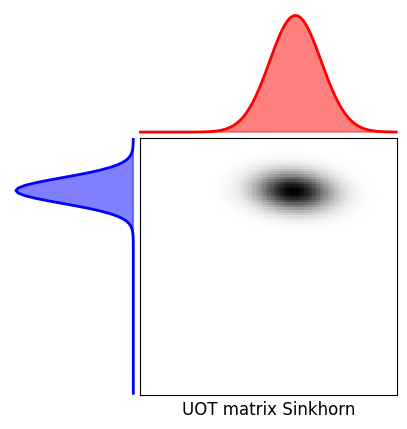

In [6]:
# Sinkhorn

epsilon = 0.1  # entropy parameter
alpha = 1.0  # Unbalanced KL relaxation parameter
Gs = ot.unbalanced.sinkhorn_unbalanced(a, b, M, epsilon, alpha, verbose=True)

pl.figure(3, figsize=(5, 5))
ot.plot.plot1D_mat(a, b, Gs, "UOT matrix Sinkhorn")

pl.show()

### Plot the transported mass

Text(0.5, 1.0, 'Distributions and transported mass for UOT')

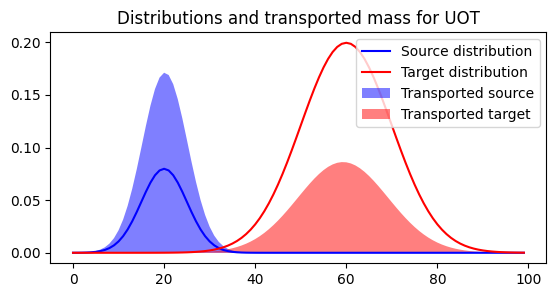

In [7]:
pl.figure(4, figsize=(6.4, 3))
pl.plot(x, a, "b", label="Source distribution")
pl.plot(x, b, "r", label="Target distribution")
pl.fill(x, Gs.sum(1), "b", alpha=0.5, label="Transported source")
pl.fill(x, Gs.sum(0), "r", alpha=0.5, label="Transported target")
pl.legend(loc="upper right")
pl.title("Distributions and transported mass for UOT")